In [1]:
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy.engine import URL
from sqlalchemy import create_engine
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
def get_db_engine():
    load_dotenv()
    db_user = os.getenv("DB_USER")
    db_password = os.getenv("DB_PASSWORD")
    db_host = os.getenv("DB_HOST")
    db_port = os.getenv("DB_PORT")
    db_name = os.getenv("DB_NAME")

    if not all([db_user, db_password, db_host, db_port, db_name]):
        raise ValueError("Missing one or more required environment variables.")

    db_url = URL.create(
        drivername="mysql+pymysql",
        username=db_user,
        password=db_password,
        host=db_host,
        port=int(db_port),
        database=db_name
    )
    engine = create_engine(db_url)
    try:
        with engine.connect() as conn:
            print("Database connection is made successfully..!")

    except Exception as e:
        raise Exception(f"Database connection failed: {e}")
    return engine

In [3]:
def process_catcher_data(engine):
    def clean_catcher_data():
        catcher = pd.read_sql("SELECT jobma_catcher_id, is_premium, subscription_status, company_size, jobma_catcher_parent FROM jobma_catcher WHERE jobma_verified IN (1, '1')", engine).copy()
        catcher.replace("", np.nan, inplace=True)
        catcher['is_premium'] = pd.to_numeric(catcher['is_premium'], errors='coerce').fillna(0).astype(int)
        catcher['subscription_status'] = pd.to_numeric(catcher['subscription_status'], errors='coerce')
        catcher['subscription_status'] = catcher['subscription_status'].replace({2: 0}).fillna(0).astype(int)
        sub_accounts = catcher['jobma_catcher_parent'].value_counts()
        catcher['sub_user'] = catcher['jobma_catcher_id'].map(sub_accounts).fillna(0).astype(int)
        mode_val = catcher['company_size'].mode()[0]
        catcher['company_size'] = catcher['company_size'].fillna(mode_val)
        return catcher

    def clean_wallet_data():
        wallet = pd.read_sql("SELECT catcher_id AS jobma_catcher_id, wallet_amount, is_unlimited FROM wallet", engine).copy()
        wallet['wallet_amount'] = pd.to_numeric(wallet['wallet_amount'], errors='coerce').fillna(0)
        wallet['is_unlimited'] = pd.to_numeric(wallet['is_unlimited'], errors='coerce').fillna(0).astype(int)
        return wallet

    def clean_subscription_data():
        subscription = pd.read_sql("SELECT catcher_id AS jobma_catcher_id, subscription_amount, currency FROM subscription_history", engine).copy()
        subscription['subscription_amount'] = pd.to_numeric(subscription['subscription_amount'], errors='coerce').fillna(0)
        subscription['subscription_amount'] = subscription['subscription_amount'].where(subscription['subscription_amount'] > 0, 0)
        subscription['subscription_amount'] = np.where(subscription['currency'] == 0, subscription['subscription_amount'].round(1), (subscription['subscription_amount'] / 85).round(1))
        subscription = subscription.groupby('jobma_catcher_id').agg(subscription_sum=('subscription_amount', 'sum'), subscription_count=('jobma_catcher_id', 'count')).reset_index()
        return subscription

    def clean_login_data():
        login = pd.read_sql("SELECT jobma_user_id AS jobma_catcher_id, jobma_last_login FROM jobma_login", engine)
        login['jobma_last_login'] = pd.to_datetime(login['jobma_last_login'], errors='coerce')
        today = pd.to_datetime('2024-06-10 11:24:30')
        login['since_last_login'] = (today - login['jobma_last_login']).dt.days
        login = login.groupby('jobma_catcher_id').agg(since_last_login=('since_last_login', 'min')).reset_index()
        since_login_filled = login['since_last_login'].fillna(float('inf'))
        bins = [0, 30, 90, 180, 365, float('inf')]
        labels = [0, 1, 2, 3, 4]
        login['since_last_login'] = pd.cut(since_login_filled, bins=bins, labels=labels, right=False)
        return login

    def clean_invitations_data():
        invitations = pd.read_sql("SELECT jobma_catcher_id, jobma_interview_mode,jobma_interview_status FROM jobma_pitcher_invitations", con=engine)
        recorded = invitations[invitations['jobma_interview_mode'].isin([1, '1'])].groupby('jobma_catcher_id').size().reset_index(name='recorded_interview_count')
        live = invitations[invitations['jobma_interview_mode'].isin([2, '2'])].groupby('jobma_catcher_id').size().reset_index(name='live_interview_count')
        invites = invitations[invitations['jobma_interview_status'].isin([0, '0'])].groupby('jobma_catcher_id').size().reset_index(name='invites_count')
        done = invitations[~invitations['jobma_interview_status'].isin([0, '0'])].groupby('jobma_catcher_id').size().reset_index(name='interview_done')
        summary = pd.merge(recorded, live, on='jobma_catcher_id', how='left')#may be need improvemnt
        summary = pd.merge(summary, invites, on='jobma_catcher_id', how='left')
        summary = pd.merge(summary, done, on='jobma_catcher_id', how='left')
        summary.fillna(0, inplace=True)
        return summary

    def clean_pre_recorded_kit_data():
        kit = pd.read_sql("SELECT catcher_id AS jobma_catcher_id FROM job_assessment_kit", engine)
        return kit.groupby('jobma_catcher_id').size().reset_index(name='pre_recorded_kit_counts')

    def clean_job_posting_data():
        postings = pd.read_sql("SELECT jobma_catcher_id FROM jobma_employer_job_posting", engine).copy()
        return postings.groupby('jobma_catcher_id').size().reset_index(name='jobs_posted')

    def working_on_merged_df(work_df):
        columns_to_sum = ['recorded_interview_count', 'live_interview_count', 'invites_count', 'interview_done', 'pre_recorded_kit_counts', 'jobs_posted']
        work_df[columns_to_sum] = work_df[columns_to_sum].fillna(0).astype(int)

        child_sums = work_df[work_df['jobma_catcher_parent'] != 0].groupby('jobma_catcher_parent')[columns_to_sum].sum()
        for col in columns_to_sum:
            work_df.loc[work_df['jobma_catcher_parent'] == 0, col] += work_df.loc[work_df['jobma_catcher_parent'] == 0, 'jobma_catcher_id'].map(child_sums[col]).fillna(0)

        sub_ac = work_df[work_df['jobma_catcher_parent'] != 0]
        min_login = sub_ac.groupby('jobma_catcher_parent')['since_last_login'].min().reset_index().rename(columns={'since_last_login': 'min_login'})
        work_df = work_df.merge(min_login, how='left', on='jobma_catcher_parent')
        work_df['since_last_login'] = np.where(work_df['jobma_catcher_parent'] != 0, work_df['min_login'], work_df['since_last_login'])
        work_df.drop(columns=['min_login'], inplace=True)

        work_df = work_df[work_df['jobma_catcher_parent'] == 0].drop('jobma_catcher_parent', axis=1)
        work_df['wallet_amount'] = work_df['wallet_amount'].fillna(0)
        work_df['subscription_sum'] = work_df['subscription_sum'].fillna(0)
        work_df['subscription_count'] = work_df['subscription_count'].fillna(0).astype(int)
        work_df['is_unlimited'] = work_df['is_unlimited'].replace('', 1).fillna(0).astype(int)
        work_df['since_last_login'] = work_df['since_last_login'].fillna(4).astype(int)
        return work_df

    # Merging everything
    catcher_df = clean_catcher_data()
    other_dfs = [clean_wallet_data(),clean_subscription_data(),clean_invitations_data(),clean_pre_recorded_kit_data(),clean_job_posting_data(),clean_login_data()]
    merged_df = catcher_df.copy()
    for df in other_dfs:
        merged_df = pd.merge(merged_df, df, how='left', on='jobma_catcher_id')

    final_df = working_on_merged_df(merged_df)
    return final_df

engine = get_db_engine()
final_df = process_catcher_data(engine)
df = final_df.drop('jobma_catcher_id', axis=1)

Database connection is made successfully..!


In [4]:
def get_preprocessor():
    categorical = ['since_last_login']
    ordinal = ['company_size']
    binary = ['is_premium', 'is_unlimited', 'subscription_status']
    numeric = ['sub_user', 'subscription_count', 'live_interview_count', 'interview_done', 'pre_recorded_kit_counts', 'invites_count', 'jobs_posted']
    log_scaled = ['subscription_sum', 'wallet_amount']

    preprocessor = ColumnTransformer([('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                                        ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical), 
                                      
                                      ('ord', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                                        ('ordinal', OrdinalEncoder(categories=[['1-25', '26-100', '101-500', '500-1000', 'More than 1000']],
                                                                                   handle_unknown='use_encoded_value', unknown_value=-1))]), ordinal),
                                      ('bin', SimpleImputer(strategy='mean'), binary),
                                      
                                      ('num', Pipeline([('imputer', SimpleImputer(strategy='mean')),
                                                        ('scale', StandardScaler())]), numeric),
                                      
                                      ('log', Pipeline([('imputer', SimpleImputer(strategy='mean')),
                                                        ('log', FunctionTransformer(np.log1p, validate=False)),
                                                        ('scale', StandardScaler())]), log_scaled)
                                     ])
    return preprocessor

def preprocess_data(df, preprocessor=None, fit=True):
    if fit or preprocessor is None:
        preprocessor = get_preprocessor()
        features = preprocessor.fit_transform(df)
    else:
        features = preprocessor.transform(df)
    return features, preprocessor

In [5]:
class ClientAutoencoder(nn.Module):
    def __init__(self, input_dim, embedding_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, embedding_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

def to_tensor(X):
    return torch.FloatTensor(X.toarray() if hasattr(X, 'toarray') else X)

def train_autoencoder(X_train, model_path, input_dim, epochs=50, batch_size=32):
    X_tensor = to_tensor(X_train)
    dataset = TensorDataset(X_tensor, X_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ClientAutoencoder(input_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in dataloader:
            inputs, _ = batch
            inputs = inputs.to(device)

            optimizer.zero_grad()
            _, outputs = model(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(dataloader):.4f}")
    torch.save(model.state_dict(), model_path)
    return model


# Loading model
def load_or_train_autoencoder(X, model_path='client_autoencoder.pth'):
    input_dim = X.shape[1]
    model = ClientAutoencoder(input_dim)
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location='cpu'))
        print("Model loaded from disk.")
    else:
        print("No model found. Training new model...")
        model = train_autoencoder(X, model_path, input_dim)
    return model

# Embedding Extraction
def extract_embeddings(model, X):
    model.eval()
    with torch.no_grad():
        tensor = to_tensor(X)
        embeddings, _ = model(tensor)
    return embeddings.cpu().numpy()


def generate_recommendations(embeddings, client_ids, top_k=5, min_similarity=0.5):
    similarity_matrix = cosine_similarity(embeddings)
    recommendations = {}
    for idx, client_id in enumerate(client_ids):
        sim_scores = similarity_matrix[idx]
        top_indices = np.argsort(sim_scores)[::-1]
        similar_clients = []
        for i in top_indices:
            if client_ids[i] == client_id:
                continue
            if sim_scores[i] >= min_similarity:
                similar_clients.append((client_ids[i], round(sim_scores[i], 4)))
            if len(similar_clients) >= top_k:
                break
        recommendations[client_id] = similar_clients
    return recommendations

# --- Entry Point ---
def get_similar_clients(input_client_id, df, top_k=5, min_similarity=0.2):
    client_ids = df['jobma_catcher_id'].values
    df_cleaned = df.drop('jobma_catcher_id', axis=1)

    features, preprocessor = preprocess_data(df_cleaned, fit=True)
    model = load_or_train_autoencoder(features)
    embeddings = extract_embeddings(model, features)
    recs = generate_recommendations(embeddings, client_ids, top_k, min_similarity)

    if input_client_id not in recs:
        print(f"Client ID {input_client_id} not in dataset.")
        return pd.DataFrame()

    similar_ids = [cid for cid, _ in recs[input_client_id]]
    scores = [score for _, score in recs[input_client_id]]
    result = df[df['jobma_catcher_id'].isin(similar_ids)].copy()
    result['similarity_score'] = scores
    return result.reset_index(drop=True)

if __name__ == "__main__":
    df = final_df
    input_id = 10521
    recommendations_df = get_similar_clients(input_id, df)
recommendations_df

Model loaded from disk.


,jobma_catcher_id,is_premium,subscription_status,company_size,sub_user,wallet_amount,is_unlimited,subscription_sum,subscription_count,recorded_interview_count,live_interview_count,invites_count,interview_done,pre_recorded_kit_counts,jobs_posted,since_last_login,similarity_score
0,8535,1,1,1-25,0,14746.0,0,197.8,8,0,0,0,0,1,19,2,0.9184
1,9620,0,1,1-25,0,500000.0,1,1.2,1,9,0,0,9,5,8,2,0.9137
2,9891,0,1,26-100,1,500000.0,1,117.6,1,65,16,0,81,19,18,2,0.8831
3,9944,0,1,1-25,0,500000.0,1,117.6,1,8,1,0,9,2,6,3,0.8597
4,10240,0,1,1-25,1,500000.0,1,117.6,1,7,2,0,9,16,9,2,0.8567


In [6]:
input_client_id = 7514
similar_clients_df = get_similar_clients(input_client_id, df)
similar_clients_df

Model loaded from disk.


,jobma_catcher_id,is_premium,subscription_status,company_size,sub_user,wallet_amount,is_unlimited,subscription_sum,subscription_count,recorded_interview_count,live_interview_count,invites_count,interview_done,pre_recorded_kit_counts,jobs_posted,since_last_login,similarity_score
0,7513,0,1,26-100,0,660.0,0,14.2,2,0,0,0,0,0,0,4,1.0000
1,7515,0,1,1-25,0,660.0,0,14.2,2,0,0,0,0,0,0,4,1.0000
2,7517,0,1,1-25,0,1860.0,0,42.4,2,0,0,0,0,0,0,4,0.9762
3,7519,0,1,1-25,0,660.0,0,14.2,2,0,0,0,0,0,0,4,0.9423
4,10506,0,1,1-25,0,200.0,0,3.0,2,0,0,0,0,0,0,4,0.9271


In [7]:
input_client_id = 6422
similar_clients_df = get_similar_clients(input_client_id, df)
similar_clients_df

Model loaded from disk.


,jobma_catcher_id,is_premium,subscription_status,company_size,sub_user,wallet_amount,is_unlimited,subscription_sum,subscription_count,recorded_interview_count,live_interview_count,invites_count,interview_done,pre_recorded_kit_counts,jobs_posted,since_last_login,similarity_score
0,7514,0,1,1-25,0,660.0,0,14.2,2,0,0,0,0,0,0,4,0.8700
1,7515,0,1,1-25,0,660.0,0,14.2,2,0,0,0,0,0,0,4,0.8700
2,7517,0,1,1-25,0,1860.0,0,42.4,2,0,0,0,0,0,0,4,0.8700
3,7519,0,1,1-25,0,660.0,0,14.2,2,0,0,0,0,0,0,4,0.8692
4,9965,0,1,1-25,1,1080.0,0,0.6,3,0,0,0,0,0,0,3,0.8492


# Details

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4466 entries, 0 to 6115
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   jobma_catcher_id          4466 non-null   int64  
 1   is_premium                4466 non-null   int64  
 2   subscription_status       4466 non-null   int64  
 3   company_size              4466 non-null   object 
 4   sub_user                  4466 non-null   int64  
 5   wallet_amount             4466 non-null   float64
 6   is_unlimited              4466 non-null   int64  
 7   subscription_sum          4466 non-null   float64
 8   subscription_count        4466 non-null   int64  
 9   recorded_interview_count  4466 non-null   int64  
 10  live_interview_count      4466 non-null   int64  
 11  invites_count             4466 non-null   int64  
 12  interview_done            4466 non-null   int64  
 13  pre_recorded_kit_counts   4466 non-null   int64  
 14  jobs_posted  

In [9]:
df.max()

jobma_catcher_id                     10536
is_premium                               1
subscription_status                      1
company_size                More than 1000
sub_user                                40
wallet_amount                    4995968.0
is_unlimited                             1
subscription_sum                 1398501.6
subscription_count                     116
recorded_interview_count              1403
live_interview_count                   480
invites_count                        12561
interview_done                       37495
pre_recorded_kit_counts                293
jobs_posted                            195
since_last_login                         4
dtype: object

In [10]:
df.min()

jobma_catcher_id            2656
is_premium                     0
subscription_status            0
company_size                1-25
sub_user                       0
wallet_amount                0.0
is_unlimited                   0
subscription_sum             0.0
subscription_count             0
recorded_interview_count       0
live_interview_count           0
invites_count                  0
interview_done                 0
pre_recorded_kit_counts        0
jobs_posted                    0
since_last_login               0
dtype: object

In [11]:
df.isna().sum()

jobma_catcher_id            0
is_premium                  0
subscription_status         0
company_size                0
sub_user                    0
wallet_amount               0
is_unlimited                0
subscription_sum            0
subscription_count          0
recorded_interview_count    0
live_interview_count        0
invites_count               0
interview_done              0
pre_recorded_kit_counts     0
jobs_posted                 0
since_last_login            0
dtype: int64

In [12]:
df.head(10)

,jobma_catcher_id,is_premium,subscription_status,company_size,sub_user,wallet_amount,is_unlimited,subscription_sum,subscription_count,recorded_interview_count,live_interview_count,invites_count,interview_done,pre_recorded_kit_counts,jobs_posted,since_last_login
0,2656,0,1,1-25,1,66666.0,1,176.5,1,7,0,0,7,4,2,1
1,2935,0,0,26-100,0,60.0,0,0.6,1,0,0,0,0,0,0,2
2,2937,0,0,101-500,0,60.0,0,1.4,1,0,0,0,0,0,0,2
3,2938,0,1,26-100,0,50.0,0,178.8,3,0,0,0,0,0,1,2
4,2939,0,0,26-100,0,60.0,0,138.8,1,0,0,0,0,0,1,4
5,2940,0,0,26-100,0,60.0,0,0.1,1,0,0,0,0,0,1,4
6,2941,0,0,26-100,0,60.0,0,138.8,1,0,0,0,0,0,1,4
7,2942,0,0,1-25,0,60.0,0,0.1,1,0,0,0,0,0,0,4
8,2943,0,0,1-25,0,60.0,0,0.1,1,0,0,0,0,0,1,4
9,2944,0,0,101-500,0,60.0,0,2.3,1,0,0,0,0,0,0,4


In [13]:
df.tail(10)

,jobma_catcher_id,is_premium,subscription_status,company_size,sub_user,wallet_amount,is_unlimited,subscription_sum,subscription_count,recorded_interview_count,live_interview_count,invites_count,interview_done,pre_recorded_kit_counts,jobs_posted,since_last_login
6102,10523,0,1,1-25,1,47.0,0,647.1,3,1,1,1,1,1,1,0
6103,10524,0,1,26-100,0,149.0,0,294.1,1,1,0,0,1,1,1,0
6104,10525,0,1,26-100,0,500000.0,1,117.6,1,0,0,0,0,1,1,0
6105,10526,0,1,101-500,0,500000.0,1,117.6,1,9,0,4,5,4,3,4
6107,10528,0,1,26-100,0,50.0,0,1.2,1,1,0,0,1,1,1,4
6108,10529,0,1,1-25,0,35.0,0,1.2,1,3,0,0,3,1,2,0
6109,10530,0,1,1-25,0,147.0,0,0.0,1,3,0,0,3,3,5,4
6110,10531,0,1,26-100,0,50.0,0,1.2,1,0,0,0,0,0,0,0
6112,10533,0,1,1-25,0,49.0,0,0.0,1,2,0,0,2,2,2,4
6115,10536,0,1,1-25,0,48.0,0,0.0,1,2,0,0,2,1,1,0


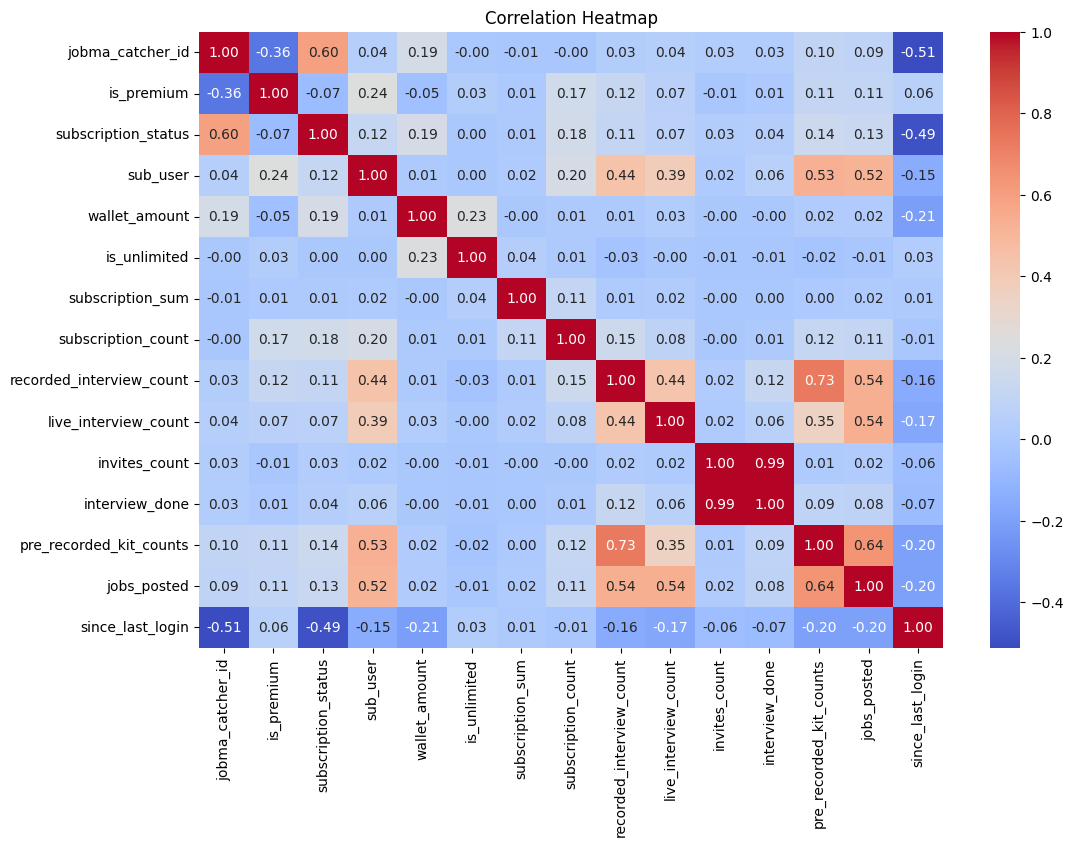

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
df

,jobma_catcher_id,is_premium,subscription_status,company_size,sub_user,wallet_amount,is_unlimited,subscription_sum,subscription_count,recorded_interview_count,live_interview_count,invites_count,interview_done,pre_recorded_kit_counts,jobs_posted,since_last_login
0,2656,0,1,1-25,1,66666.0,1,176.5,1,7,0,0,7,4,2,1
1,2935,0,0,26-100,0,60.0,0,0.6,1,0,0,0,0,0,0,2
2,2937,0,0,101-500,0,60.0,0,1.4,1,0,0,0,0,0,0,2
3,2938,0,1,26-100,0,50.0,0,178.8,3,0,0,0,0,0,1,2
4,2939,0,0,26-100,0,60.0,0,138.8,1,0,0,0,0,0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6108,10529,0,1,1-25,0,35.0,0,1.2,1,3,0,0,3,1,2,0
6109,10530,0,1,1-25,0,147.0,0,0.0,1,3,0,0,3,3,5,4
6110,10531,0,1,26-100,0,50.0,0,1.2,1,0,0,0,0,0,0,0
6112,10533,0,1,1-25,0,49.0,0,0.0,1,2,0,0,2,2,2,4


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4466 entries, 0 to 6115
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   jobma_catcher_id          4466 non-null   int64  
 1   is_premium                4466 non-null   int64  
 2   subscription_status       4466 non-null   int64  
 3   company_size              4466 non-null   object 
 4   sub_user                  4466 non-null   int64  
 5   wallet_amount             4466 non-null   float64
 6   is_unlimited              4466 non-null   int64  
 7   subscription_sum          4466 non-null   float64
 8   subscription_count        4466 non-null   int64  
 9   recorded_interview_count  4466 non-null   int64  
 10  live_interview_count      4466 non-null   int64  
 11  invites_count             4466 non-null   int64  
 12  interview_done            4466 non-null   int64  
 13  pre_recorded_kit_counts   4466 non-null   int64  
 14  jobs_posted  

In [17]:
df.max()

jobma_catcher_id                     10536
is_premium                               1
subscription_status                      1
company_size                More than 1000
sub_user                                40
wallet_amount                    4995968.0
is_unlimited                             1
subscription_sum                 1398501.6
subscription_count                     116
recorded_interview_count              1403
live_interview_count                   480
invites_count                        12561
interview_done                       37495
pre_recorded_kit_counts                293
jobs_posted                            195
since_last_login                         4
dtype: object

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
jobma_catcher_id,4466.0,6440.853784,2131.811981,2656.0,4654.25,6410.5,7876.75,10536.0
is_premium,4466.0,0.219436,0.413911,0.0,0.00,0.0,0.00,1.0
subscription_status,4466.0,0.247649,0.431695,0.0,0.00,0.0,0.00,1.0
sub_user,4466.0,0.368786,1.274578,0.0,0.00,0.0,0.00,40.0
wallet_amount,4466.0,13742.268921,107823.445426,0.0,60.00,60.0,60.00,4995968.0
is_unlimited,4466.0,0.188312,0.391005,0.0,0.00,0.0,0.00,1.0
subscription_sum,4466.0,1255.158419,30218.493399,0.0,1.20,11.8,176.50,1398501.6
subscription_count,4466.0,2.115987,3.433382,0.0,1.00,1.0,2.00,116.0
recorded_interview_count,4466.0,7.152485,59.610413,0.0,0.00,0.0,0.00,1403.0
live_interview_count,4466.0,0.490820,8.342153,0.0,0.00,0.0,0.00,480.0


In [19]:
df.min()

jobma_catcher_id            2656
is_premium                     0
subscription_status            0
company_size                1-25
sub_user                       0
wallet_amount                0.0
is_unlimited                   0
subscription_sum             0.0
subscription_count             0
recorded_interview_count       0
live_interview_count           0
invites_count                  0
interview_done                 0
pre_recorded_kit_counts        0
jobs_posted                    0
since_last_login               0
dtype: object

In [20]:
df.nunique()

jobma_catcher_id            4466
is_premium                     2
subscription_status            2
company_size                   5
sub_user                      19
wallet_amount                179
is_unlimited                   2
subscription_sum             733
subscription_count            35
recorded_interview_count     130
live_interview_count          34
invites_count                 28
interview_done               129
pre_recorded_kit_counts       55
jobs_posted                   55
since_last_login               5
dtype: int64

In [21]:
df.columns

Index(['jobma_catcher_id', 'is_premium', 'subscription_status', 'company_size',
       'sub_user', 'wallet_amount', 'is_unlimited', 'subscription_sum',
       'subscription_count', 'recorded_interview_count',
       'live_interview_count', 'invites_count', 'interview_done',
       'pre_recorded_kit_counts', 'jobs_posted', 'since_last_login'],
      dtype='object')